# EDA

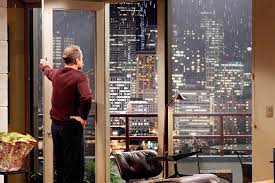

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

## Load the data

In [2]:
from pathlib import Path

data_dir = Path("data")
csv_path = next(data_dir.glob("*.csv"))

df = pd.read_csv(csv_path)
print(f"Loaded {csv_path.name}")
df.head()

Loaded _SELECT_kchd_kchs_date_kchs_price_FROM_eda_king_county_house_det_202609161451.csv


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


## Descriptive statistics

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 21597, Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21597.000,NaN,NaN,NaN,4580474287.771,2876735715.748,1000102.000,2123049175.000,3904930410.000,7308900490.000,9900000190.000
bedrooms,21597.000,NaN,NaN,NaN,3.373,0.926,1.000,3.000,3.000,4.000,33.000
bathrooms,21597.000,NaN,NaN,NaN,2.116,0.769,0.500,1.750,2.250,2.500,8.000
sqft_living,21597.000,NaN,NaN,NaN,2080.322,918.106,370.000,1430.000,1910.000,2550.000,13540.000
sqft_lot,21597.000,NaN,NaN,NaN,15099.409,41412.637,520.000,5040.000,7618.000,10685.000,1651359.000
floors,21597.000,NaN,NaN,NaN,1.494,0.540,1.000,1.000,1.500,2.000,3.500
waterfront,19206.000,NaN,NaN,NaN,0.008,0.087,0.000,0.000,0.000,0.000,1.000
view,21534.000,NaN,NaN,NaN,0.234,0.766,0.000,0.000,0.000,0.000,4.000
condition,21597.000,NaN,NaN,NaN,3.410,0.651,1.000,3.000,3.000,4.000,5.000
grade,21597.000,NaN,NaN,NaN,7.658,1.173,3.000,7.000,7.000,8.000,13.000


## Distributions

### Continuous variables

Numeric columns that can take a wide range of values (as opposed to a fixed set of categories).

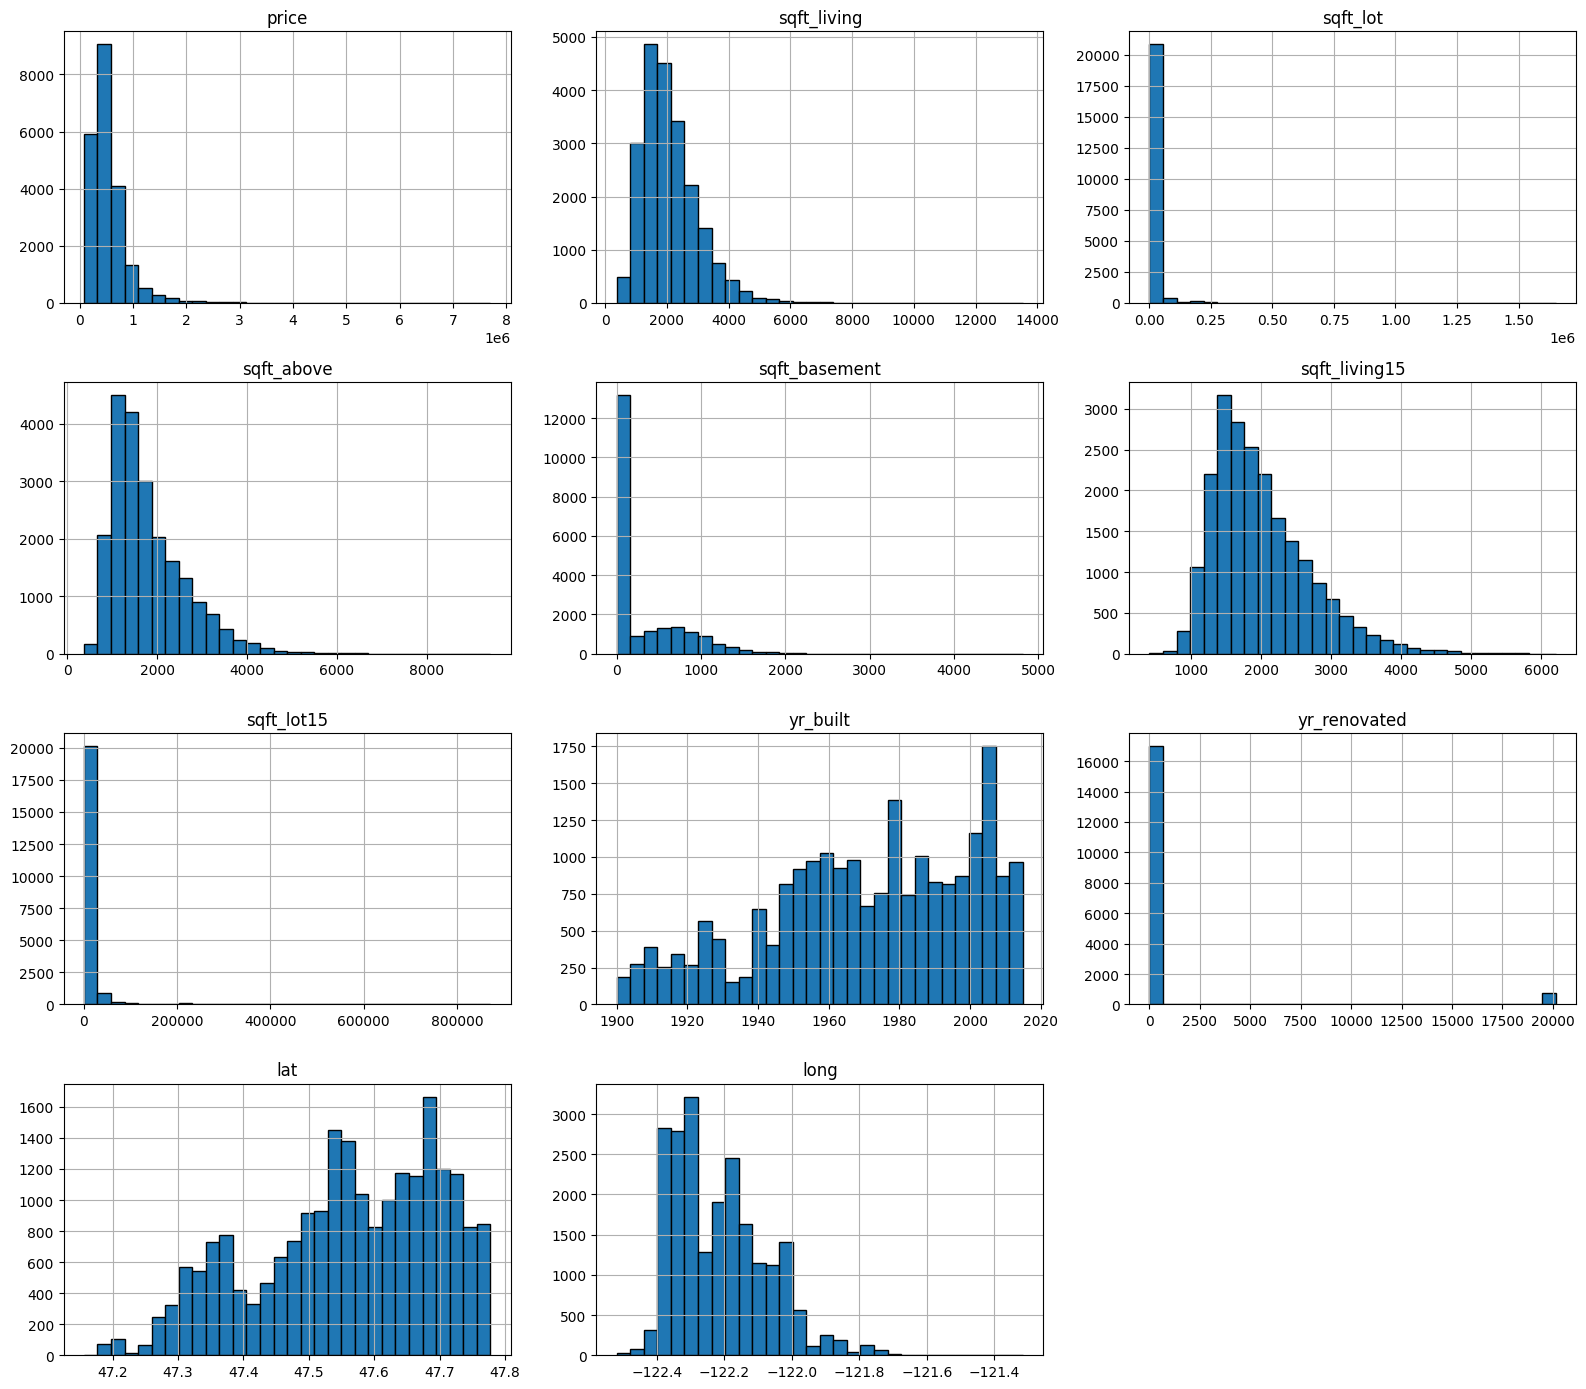

In [5]:
continuous_cols = [
    "price",
    "sqft_living",
    "sqft_lot",
    "sqft_above",
    "sqft_basement",
    "sqft_living15",
    "sqft_lot15",
    "yr_built",
    "yr_renovated",
    "lat",
    "long",
]  # numeric columns to check for skew/shape below

df[continuous_cols].hist(bins=30, figsize=(16, 14), edgecolor="black")  # one histogram per column, grid layout
plt.tight_layout()  # avoid overlapping titles/labels
plt.show()  # render the figure

In [6]:
# Skewness: 0 = symmetric, >1 or <-1 = strongly skewed
# IQR outlier count: values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
skew_stats = df[continuous_cols].skew().rename("skewness")  # skewness per column

q1 = df[continuous_cols].quantile(0.25)  # 25th percentile per column
q3 = df[continuous_cols].quantile(0.75)  # 75th percentile per column
iqr = q3 - q1  # interquartile range
lower_bound = q1 - 1.5 * iqr  # anything below this counts as a low outlier
upper_bound = q3 + 1.5 * iqr  # anything above this counts as a high outlier
outlier_count = (
    (df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)
).sum().rename("outliers_iqr")  # count of rows outside the IQR bounds, per column
outlier_pct = (outlier_count / len(df) * 100).rename("outliers_pct")  # same count as a % of all rows

pd.concat([skew_stats, outlier_count, outlier_pct], axis=1).sort_values(
    "skewness", ascending=False
)  # combine into one table, most-skewed columns first

,skewness,outliers_iqr,outliers_pct
sqft_lot,13.073,2419,11.201
sqft_lot15,9.524,2188,10.131
yr_renovated,4.573,744,3.445
price,4.023,1158,5.362
sqft_basement,1.574,484,2.241
sqft_living,1.473,571,2.644
sqft_above,1.447,610,2.824
sqft_living15,1.107,543,2.514
long,0.885,255,1.181
yr_built,-0.469,0,0.000


### Categorical variables

Columns with a fixed, limited set of values.

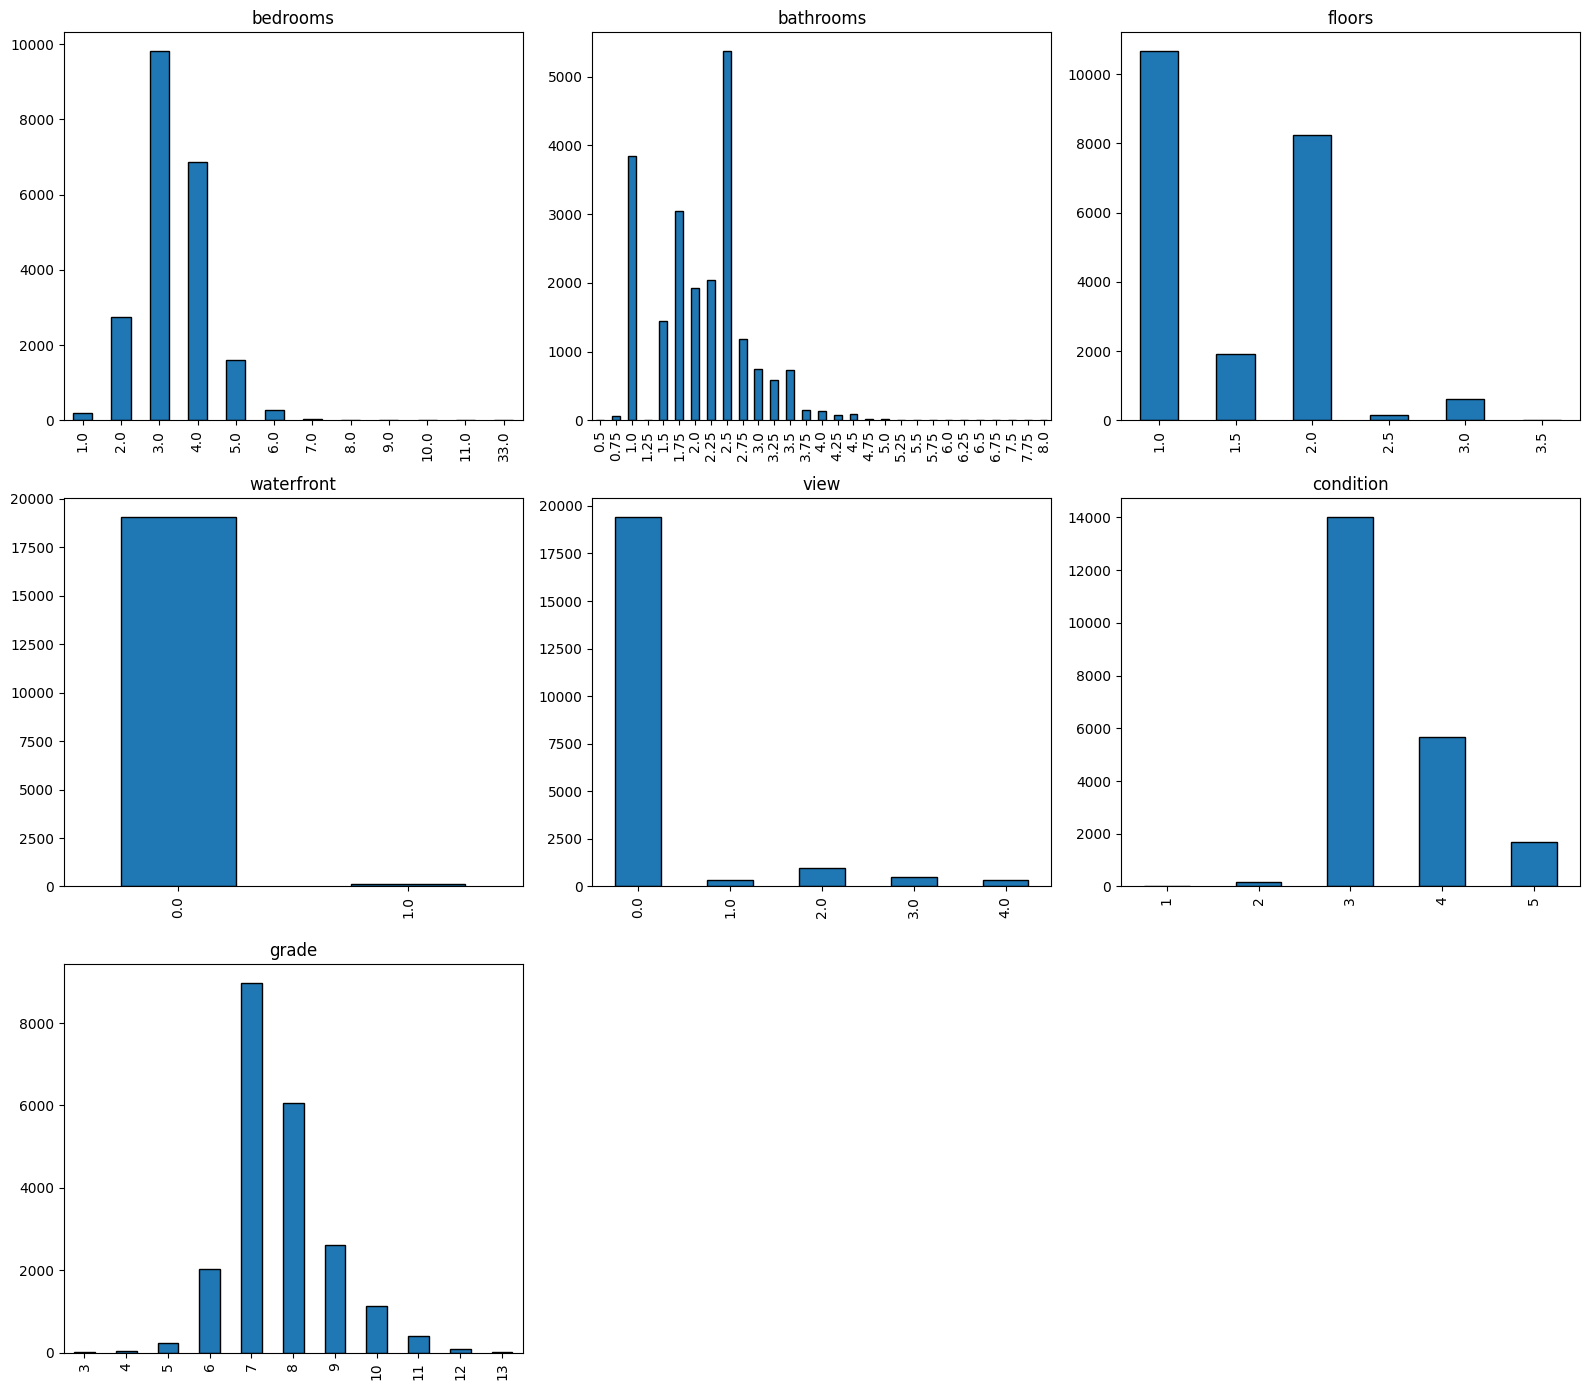

In [7]:
categorical_cols = ["bedrooms", "bathrooms", "floors", "waterfront", "view", "condition", "grade"]  # fixed-choice columns to chart

fig, axes = plt.subplots(3, 3, figsize=(16, 14))  # grid of subplots, more slots than columns
axes = axes.flatten()  # turn the 3x3 grid into a flat list for easy looping

for ax, col in zip(axes, categorical_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, edgecolor="black")  # bar chart of counts per category
    ax.set_title(col)
    ax.set_xlabel("")  # category labels are self-explanatory, skip the axis title

for ax in axes[len(categorical_cols):]:
    ax.axis("off")  # hide unused subplot slots

plt.tight_layout()
plt.show()

In [8]:
# exact counts + share of total behind each bar above
for col in categorical_cols:
    counts = df[col].value_counts().sort_index()  # number of rows per category
    share = (counts / len(df) * 100).round(1)  # same counts as a % of all rows
    print(pd.concat([counts.rename("count"), share.rename("pct")], axis=1))  # print side by side
    print()  # blank line between columns

          count    pct
bedrooms              
1.000       196  0.900
2.000      2760 12.800
3.000      9824 45.500
4.000      6882 31.900
5.000      1601  7.400
6.000       272  1.300
7.000        38  0.200
8.000        13  0.100
9.000         6  0.000
10.000        3  0.000
11.000        1  0.000
33.000        1  0.000

           count    pct
bathrooms              
0.500          4  0.000
0.750         71  0.300
1.000       3851 17.800
1.250          9  0.000
1.500       1445  6.700
1.750       3048 14.100
2.000       1930  8.900
2.250       2047  9.500
2.500       5377 24.900
2.750       1185  5.500
3.000        753  3.500
3.250        589  2.700
3.500        731  3.400
3.750        155  0.700
4.000        136  0.600
4.250         79  0.400
4.500        100  0.500
4.750         23  0.100
5.000         21  0.100
5.250         13  0.100
5.500         10  0.000
5.750          4  0.000
6.000          6  0.000
6.250          2  0.000
6.500          2  0.000
6.750          2  0.000
7.500

### zipcode — a high-cardinality categorical

Too many distinct values for a readable bar chart of all of them, so look at the top ones instead.

Unique zipcodes: 70
count    70.000
mean    308.529
std     142.224
min      50.000
25%     204.250
50%     282.500
75%     408.250
max     602.000
Name: count, dtype: float64


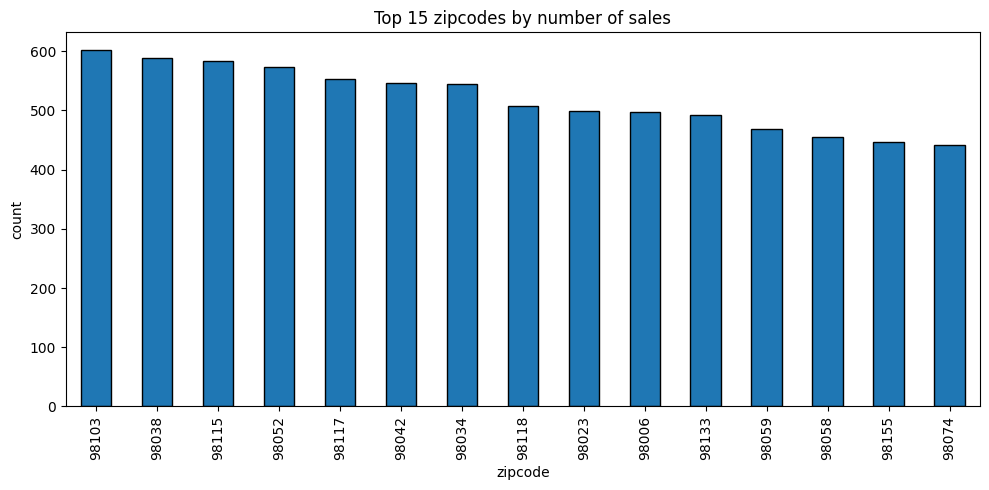

In [9]:
print(f"Unique zipcodes: {df['zipcode'].nunique()}")  # how many distinct zipcodes exist
print(df["zipcode"].value_counts().describe())  # summary stats of sales-per-zipcode

df["zipcode"].value_counts().head(15).plot(kind="bar", edgecolor="black", figsize=(10, 5))  # top 15 zipcodes by sale count
plt.title("Top 15 zipcodes by number of sales")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### SQL equivalents (run these in DBeaver against the source table)

**Continuous variable summary** (mean, spread, percentiles — the SQL version of `.describe()`):

```sql
SELECT
    AVG(price)                                          AS mean_price,
    STDDEV(price)                                       AS stddev_price,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price)  AS q1_price,
    PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price)  AS median_price,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price)  AS q3_price,
    MIN(price)                                          AS min_price,
    MAX(price)                                          AS max_price
FROM eda.king_county_house_sales;
```

**Histogram-style bucketing** (counts per price range, same idea as `.hist()`):

```sql
SELECT
    WIDTH_BUCKET(price, 0, 2000000, 20) AS price_bucket,
    COUNT(*)                            AS num_sales
FROM eda.king_county_house_sales
GROUP BY price_bucket
ORDER BY price_bucket;
```

**Categorical value counts** (the SQL version of `.value_counts()`):

```sql
SELECT
    grade,
    COUNT(*)                                            AS num_sales,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS pct
FROM eda.king_county_house_sales
GROUP BY grade
ORDER BY grade;
```

**IQR outlier bounds** (the SQL version of the outlier check above — swap `price` for any continuous column):

```sql
WITH quartiles AS (
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price) AS q3
    FROM eda.king_county_house_sales
)
SELECT
    q1, q3, (q3 - q1) AS iqr,
    q1 - 1.5 * (q3 - q1) AS lower_bound,
    q3 + 1.5 * (q3 - q1) AS upper_bound
FROM quartiles;
```

## Assumptions
- For a person who wants to live in a lively central neighbourhood, I assume downtowns of the 5 highest populated cities are the most suitable: houses located within 5 miles of a major downtown (Seattle, Bellevue, Kent, Renton, or Federal Way).
- I assume Nicole has no children and is looking for a one or max two bedroom 45-60sqm (485 - 645 sqft) apartment.
- I assume timing and price are important for Nicole, but she has to take seasonality into account to find the best deal.
## Hypotheses
- Houses located within 5 miles of a major downtown (Seattle, Bellevue, Kent, Renton, or Federal Way) have a median price at least 50% higher than houses outside that radius.
- Neighborhoods where nearby homes have smaller lot sizes (lower sqft_lot15) are denser and more likely to be urban/lively areas, versus neighborhoods with large sqft_lot15 values which are more likely suburban/spread out.
- In summer the sales are up to and in winter the houses are up to 5% be cheaper.

## Data cleaning

### Missing values

Recap of what's missing, before deciding how to handle each column.

In [10]:
missing = df.isna().sum()  # count of missing values per column
missing_pct = (missing / len(df) * 100).round(2)  # same counts as a % of all rows
pd.concat([missing.rename("missing"), missing_pct.rename("pct")], axis=1)[missing > 0]  # only show columns that actually have missing values

,missing,pct
waterfront,2391,11.070
view,63,0.290
sqft_basement,452,2.090
yr_renovated,3848,17.820


**Decisions per column** (impute rather than drop rows — each gap has a defensible fill value, so dropping rows would throw away good data in the other 20 columns):

- `sqft_basement` (2.1% missing): every non-missing row satisfies `sqft_above + sqft_basement == sqft_living`, so the missing basement values can be derived exactly (and they all resolve to 0 — the house has no basement).
- `view` (0.3% missing): 90% of known values are `0` ("no view"), so impute with 0 — negligible impact either way at this size.
- `yr_renovated` (17.8% missing): unknown renovation status. Impute with `0` (matches ~96% of known values) but first save a `was_renovated` flag so we don't quietly lose the "renovated at some point" signal for real cases.
- `waterfront` (11.1% missing): only 0.7% of known values are waterfront, so impute the missing 11% with `0` too — the assumption is that most unlabeled houses are not waterfront, which matches the base rate.

In [11]:
# work on a copy so `df` stays the raw, untouched dataset for comparison
df_clean = df.copy()

In [12]:
df_clean["sqft_basement"] = df_clean["sqft_basement"].fillna(df_clean["sqft_living"] - df_clean["sqft_above"])  # missing basement size = living area minus above-ground area
df_clean["view"] = df_clean["view"].fillna(0)  # missing view rating -> assume no view
df_clean["was_renovated"] = (df_clean["yr_renovated"].fillna(0) > 0).astype(int)  # flag: was the house ever renovated (before nulling out yr_renovated below)
df_clean["yr_renovated"] = df_clean["yr_renovated"].fillna(0)  # missing renovation year -> 0 (never renovated)
df_clean["waterfront"] = df_clean["waterfront"].fillna(0)  # missing waterfront flag -> assume not waterfront

df_clean.isna().sum()[df_clean.isna().sum() > 0]  # should be empty

Series([], dtype: int64)

### Outliers and data errors

Two things came up while checking the categorical distributions:

1. A house listed with **33 bedrooms** in only 1,620 sqft (~49 sqft/bedroom) — almost certainly a typo, not a real property. There's also an 11-bedroom / 3,000 sqft house, which is odd but at least physically plausible (e.g. a converted rental), so it's left in.
2. **177 duplicate `id` values** — these are *not* data errors, they're houses that sold more than once in the time window (same property, different sale price/date). Keep them; removing them would delete legitimate re-sales.

The heavy skew in `sqft_lot`/`sqft_lot15`/`price` seen earlier isn't being treated as "outliers to remove" — those are real large lots and expensive homes, not data errors. They're handled with a transform instead (next section).

In [ ]:
print(f"max bedrooms: {df['bedrooms'].max():.0f}")  # confirms the 33-bedroom outlier
display(df[df["bedrooms"] == df["bedrooms"].max()][["id", "bedrooms", "bathrooms", "sqft_living", "price"]])  # the actual offending row(s)

duplicate_ids = df["id"].duplicated()  # True for every re-occurrence of an id beyond its first sale
print(f"\nduplicate id rows: {duplicate_ids.sum()}")  # confirms the 177 repeat sales
df.loc[df["id"].duplicated(keep=False), ["id", "date", "price"]].sort_values("id").head(10)  # sample of houses that sold more than once

In [13]:
rows_before = len(df_clean)  # row count before dropping bad data

df_clean = df_clean[df_clean["bedrooms"] < 33].copy()  # drop the data-entry error (33-bedroom house)

rows_after = len(df_clean)  # row count after dropping
print(f"Dropped {rows_before - rows_after} row(s): {rows_before} -> {rows_after}")

Dropped 1 row(s): 21597 -> 21596


### How much data did we throw away?

Almost none. 1 row out of 21,597 (~0.005%) was dropped as a data-entry error. Every missing value was imputed rather than dropped — so no legitimate houses were removed from the dataset.

In [ ]:
# df = raw data, df_clean = cleaned data — compare them directly
print(f"df       : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"df_clean : {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

print("\nmissing values, before vs after:")
print(
    pd.concat(
        [df.isna().sum().rename("df_missing"), df_clean.isna().sum().rename("df_clean_missing")],
        axis=1,
    )  # missing-value counts per column, before and after cleaning
)

print("\nnew columns added in df_clean:", set(df_clean.columns) - set(df.columns))  # columns created during cleaning/feature engineering

## Hypothesis 1: downtown vs. outskirts pricing

**How "downtown" and "outskirts" are defined:**
- **Downtown** — a house whose straight-line distance to the *closest* of the 5 city centers (Seattle, Bellevue, Kent, Renton, Federal Way) is **5 miles or less**. It's tagged with that city's name in `closest_town`.
- **Outskirts** — a house that is more than 5 miles from *all 5* city centers. Tagged `"Other"` in `closest_town`.
- Distance is straight-line (haversine), not driving distance — a simplification, not actual commute time.
- The 5-mile radius is our own assumption, not derived from the data (matches Nicole's preference for a "lively central neighbourhood" from the Assumptions section above). A different radius would shift houses between the two groups, especially ones near the 5-mile boundary.

Computed for the whole cleaned dataset (`df_clean`), not just the 1-2 bedroom bucket, so it's reusable for other slices later.

In [16]:
import numpy as np

# Approx. downtown coordinates for the 5 biggest King County cities
DOWNTOWNS = {
    "Seattle": (47.6062, -122.3321),
    "Bellevue": (47.6101, -122.2015),
    "Kent": (47.3809, -122.2348),
    "Renton": (47.4829, -122.2171),
    "Federal Way": (47.3223, -122.3126),
}  # (lat, long) of each city center
DOWNTOWN_RADIUS_MI = 5  # a house within this many miles of a downtown counts as "downtown"


def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles between (lat1, lon1) and (lat2, lon2)."""
    earth_radius_mi = 3958.8
    lat1, lon1, lat2, lon2 = (np.radians(x) for x in (lat1, lon1, lat2, lon2))  # trig functions need radians, not degrees
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2  # haversine formula
    return 2 * earth_radius_mi * np.arcsin(np.sqrt(a))


# distance from every house to each of the 5 downtowns
dist_to_downtowns = pd.DataFrame(
    {
        town: haversine_miles(df_clean["lat"], df_clean["long"], lat, lon)
        for town, (lat, lon) in DOWNTOWNS.items()
    }
)  # one column per downtown, one row per house

df_clean["dist_to_downtown_mi"] = dist_to_downtowns.min(axis=1)  # distance to the *nearest* downtown
df_clean["closest_town"] = dist_to_downtowns.idxmin(axis=1)  # name of that nearest downtown
df_clean.loc[df_clean["dist_to_downtown_mi"] > DOWNTOWN_RADIUS_MI, "closest_town"] = "Other"  # too far from any downtown -> outskirts

df_clean["closest_town"].value_counts()  # how many houses fall into each town/"Other"

closest_town
Other          11436
Seattle         3467
Renton          2296
Bellevue        1857
Kent            1274
Federal Way     1266
Name: count, dtype: int64

### Sanity-check the tagging on a map

Before trusting `closest_town`, plot every house by (lat, long), colored by its tag, with the 5 downtown points marked — the 5-mile radius should show up as visible clusters around each downtown, surrounded by "Other".

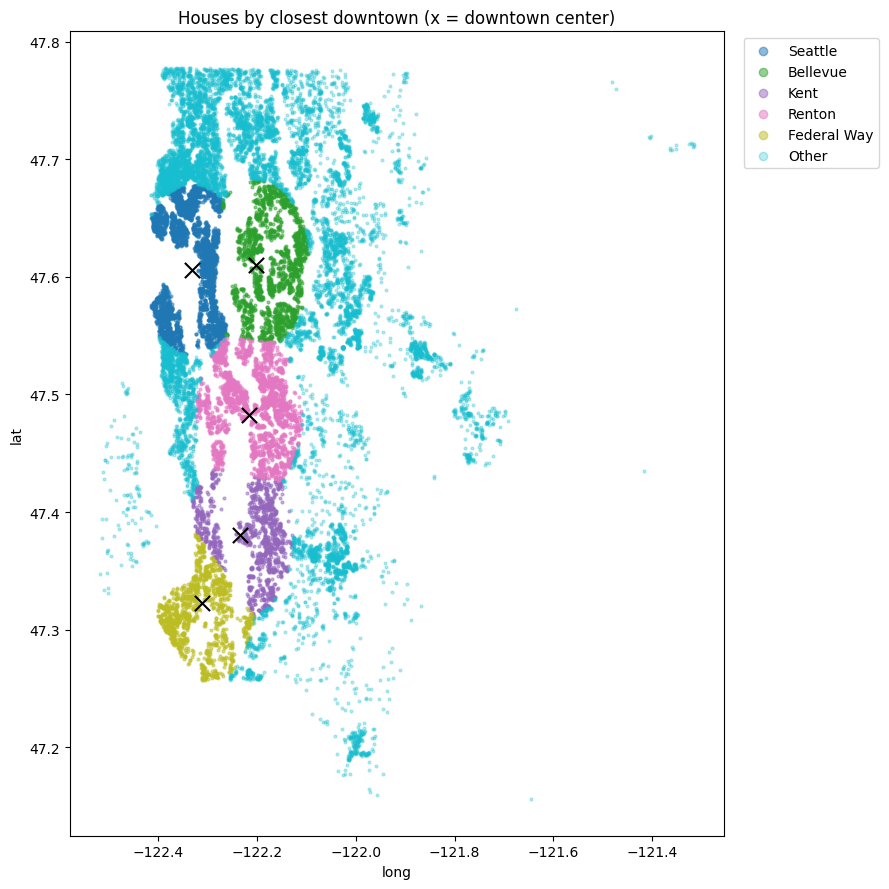

In [17]:
town_order = [*DOWNTOWNS.keys(), "Other"]  # legend/plot order: downtowns first, then outskirts
colors = plt.cm.tab10(np.linspace(0, 1, len(town_order)))  # one distinct color per town
color_map = dict(zip(town_order, colors))

fig, ax = plt.subplots(figsize=(9, 9))
for town in town_order:
    subset = df_clean[df_clean["closest_town"] == town]  # just this town's houses
    ax.scatter(
        subset["long"],
        subset["lat"],
        s=4,
        alpha=0.3 if town == "Other" else 0.5,  # fade "Other" slightly so downtown clusters stand out
        color=color_map[town],
        label=town,
    )

for town, (lat, lon) in DOWNTOWNS.items():
    ax.scatter(lon, lat, marker="x", s=120, color="black", zorder=5)  # mark each downtown's actual center

ax.set_xlabel("long")
ax.set_ylabel("lat")
ax.set_title("Houses by closest downtown (x = downtown center)")
ax.legend(markerscale=3, loc="upper left", bbox_to_anchor=(1.02, 1))  # legend outside the plot area
plt.tight_layout()
plt.show()

### Price distribution by town

`price` on a log scale (heavily skewed — see the earlier distributions section), boxplot per `closest_town`, ordered by median price so the downtown-vs-outskirts pattern is easy to read.

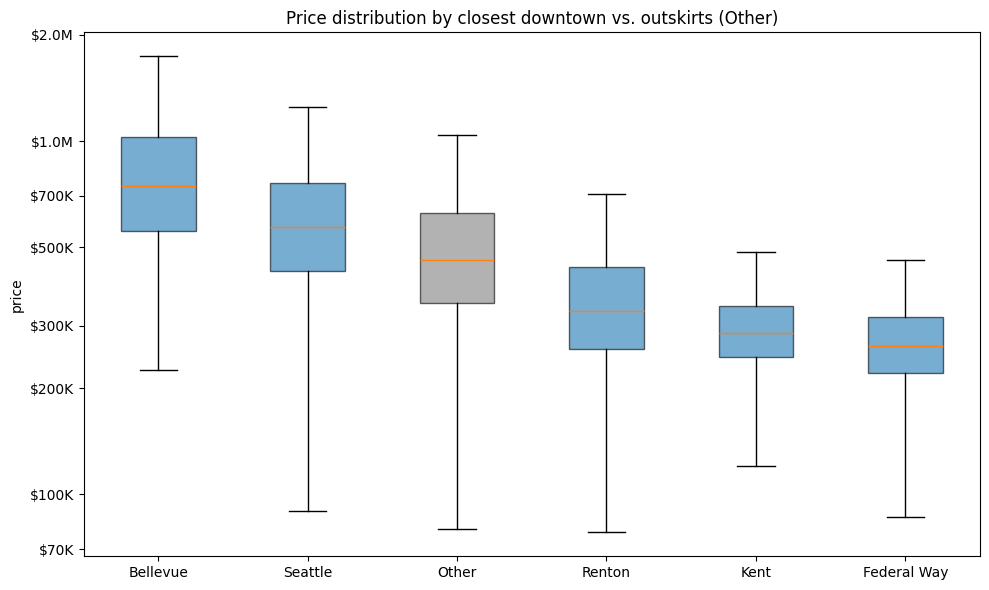

closest_town
Bellevue      745000.000
Seattle       569950.000
Other         460000.000
Renton        330000.000
Kent          286542.500
Federal Way   262250.000
Name: median_price, dtype: float64

In [18]:
import matplotlib.ticker as mticker

order_by_median = (
    df_clean.groupby("closest_town")["price"].median().sort_values(ascending=False).index
)  # towns sorted highest to lowest median price
data_by_town = [df_clean.loc[df_clean["closest_town"] == town, "price"] for town in order_by_median]  # price values per town, in that order

fig, ax = plt.subplots(figsize=(10, 6))
box_colors = ["tab:gray" if town == "Other" else "tab:blue" for town in order_by_median]  # gray out "Other" so downtowns stand out
bp = ax.boxplot(data_by_town, labels=order_by_median, patch_artist=True, showfliers=False)  # hide outlier points to keep the plot readable
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)


def format_price(value, _pos):
    """axis tick label, e.g. 250_000 -> '$250K', 1_500_000 -> '$1.5M'"""
    if value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    return f"${value / 1_000:.0f}K"


ax.set_yscale("log")  # log scale since price is heavily skewed
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0, 7.0)))  # more tick marks than default log scale gives
ax.yaxis.set_minor_locator(mticker.NullLocator())  # no minor ticks, keep it clean
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_price))  # show ticks as $ amounts, not raw numbers
ax.set_ylabel("price")
ax.set_title("Price distribution by closest downtown vs. outskirts (Other)")
plt.tight_layout()
plt.show()

df_clean.groupby("closest_town")["price"].median().reindex(order_by_median).rename("median_price")  # median price table, same order as the chart

### Testing hypothesis 1 on the 1-2 bedroom bucket

Filter to Nicole's target bucket (`bedrooms` in {1, 2}), split into downtown (`closest_town != "Other"`, pooling all 5 cities as the hypothesis is worded) vs. outskirts (`closest_town == "Other"`), and compare median price. Used a Mann-Whitney U test rather than a t-test since price is skewed and this is a median comparison, not a means comparison.

In [19]:
target_bucket = df_clean[df_clean["bedrooms"].isin([1, 2])].copy()  # restrict to 1-2 bedroom homes for this test
target_bucket["is_downtown"] = target_bucket["closest_town"] != "Other"  # True = in a downtown, False = outskirts

group_sizes = target_bucket["is_downtown"].value_counts().rename({True: "downtown", False: "outskirts"})  # how many homes land in each group
group_sizes

is_downtown
outskirts    1578
downtown     1378
Name: count, dtype: int64

In [20]:
downtown_price = target_bucket.loc[target_bucket["is_downtown"], "price"]  # prices of downtown homes
outskirts_price = target_bucket.loc[~target_bucket["is_downtown"], "price"]  # prices of outskirts homes

median_downtown = downtown_price.median()
median_outskirts = outskirts_price.median()
pct_diff = (median_downtown / median_outskirts - 1) * 100  # % difference, downtown vs. outskirts

print(f"downtown median price:  ${median_downtown:,.0f}  (n={len(downtown_price)})")
print(f"outskirts median price: ${median_outskirts:,.0f}  (n={len(outskirts_price)})")
print(f"downtown is {pct_diff:.1f}% {'higher' if pct_diff >= 0 else 'lower'} than outskirts")
print(f"clears the 'at least 50% higher' bar: {pct_diff >= 50}")

downtown median price:  $371,750  (n=1378)
outskirts median price: $361,250  (n=1578)
downtown is 2.9% higher than outskirts
clears the 'at least 50% higher' bar: False


In [21]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(downtown_price, outskirts_price, alternative="greater")  # test: is downtown price greater than outskirts?
alpha = 0.05  # significance threshold

print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"p-value (one-sided, downtown > outskirts): {p_value:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value < alpha}")

Mann-Whitney U statistic: 1,089,492
p-value (one-sided, downtown > outskirts): 0.4613
statistically significant at alpha=0.05: False


### Seattle only vs. outskirts

Pooling all 5 downtowns diluted the effect — Kent, Renton, and Federal Way pulled the "downtown" median down. Seattle had the highest median in the full-dataset boxplot, so check it on its own for the same 1-2 bedroom bucket.

In [22]:
seattle_price = target_bucket.loc[target_bucket["closest_town"] == "Seattle", "price"]  # prices of Seattle-only homes
outskirts_price = target_bucket.loc[target_bucket["closest_town"] == "Other", "price"]  # prices of outskirts homes

median_seattle = seattle_price.median()
median_outskirts = outskirts_price.median()
pct_diff_seattle = (median_seattle / median_outskirts - 1) * 100  # % difference, Seattle vs. outskirts

print(f"Seattle median price:   ${median_seattle:,.0f}  (n={len(seattle_price)})")
print(f"outskirts median price: ${median_outskirts:,.0f}  (n={len(outskirts_price)})")
print(f"Seattle is {pct_diff_seattle:.1f}% {'higher' if pct_diff_seattle >= 0 else 'lower'} than outskirts")
print(f"clears the 'at least 50% higher' bar: {pct_diff_seattle >= 50}")

Seattle median price:   $447,500  (n=851)
outskirts median price: $361,250  (n=1578)
Seattle is 23.9% higher than outskirts
clears the 'at least 50% higher' bar: False


In [23]:
stat_sea, p_value_sea = mannwhitneyu(seattle_price, outskirts_price, alternative="greater")  # test: is Seattle price greater than outskirts?

print(f"Mann-Whitney U statistic: {stat_sea:,.0f}")
print(f"p-value (one-sided, Seattle > outskirts): {p_value_sea:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value_sea < alpha}")

Mann-Whitney U statistic: 891,570
p-value (one-sided, Seattle > outskirts): 5.99e-41
statistically significant at alpha=0.05: True


### All 5 downtowns vs. outskirts, individually

Same test as above, generalized to each of the 5 cities (not just Seattle), each compared against the same outskirts group. This is the clean way to see which specific downtowns actually carry a price premium for 1-2 bedroom homes, instead of one pooled or one single-city number.

In [24]:
results = []
for town in DOWNTOWNS:
    town_price = target_bucket.loc[target_bucket["closest_town"] == town, "price"]  # prices of this town's homes
    median_town = town_price.median()
    pct_diff = (median_town / median_outskirts - 1) * 100  # % difference vs. outskirts
    stat, p = mannwhitneyu(town_price, outskirts_price, alternative="greater")  # test: is this town's price greater than outskirts?
    results.append(
        {
            "city": town,
            "n": len(town_price),
            "median_price": median_town,
            "pct_diff_vs_outskirts": round(pct_diff, 1),
            "clears_50pct_bar": pct_diff >= 50,
            "p_value": p,
            "significant": p < alpha,
        }
    )

results_df = pd.DataFrame(results).set_index("city").sort_values("median_price", ascending=False)  # one row per city, highest price first

print(f"outskirts median price for comparison: ${median_outskirts:,.0f}  (n={len(outskirts_price)})")
print()

display_df = results_df.copy()
display_df["median_price"] = display_df["median_price"].map(lambda x: f"${x:,.0f}")  # format as currency for display
display_df["p_value"] = display_df["p_value"].map(lambda x: f"{x:.2e}")  # format in scientific notation for display
display_df

outskirts median price for comparison: $361,250  (n=1578)



,n,median_price,pct_diff_vs_outskirts,clears_50pct_bar,p_value,significant
city,,,,,,
Bellevue,49,"$660,000",82.700,True,3.21e-17,True
Seattle,851,"$447,500",23.900,False,5.99e-41,True
Renton,307,"$225,000",-37.700,False,1.00e+00,False
Kent,85,"$210,000",-41.900,False,1.00e+00,False
Federal Way,86,"$199,950",-44.700,False,1.00e+00,False


## Mid-price range per downtown

**Defining "mid-price":** for each of the 5 downtowns, using Nicole's target bucket (1-2 bedroom homes), the mid-price range is the **interquartile range (IQR) of `price`** — the 25th to 75th percentile of what actually sold there. That's the middle 50% of the market: wide enough to be a realistic price to shop in, narrow enough to exclude the cheapest fixer-uppers and the priciest outliers at either end.

`"Other"` (outskirts) is excluded from this step — Nicole specifically wants a downtown, so only the 5 downtown groups get a mid-price band.

In [25]:
downtown_bucket = target_bucket[target_bucket["closest_town"] != "Other"].copy()  # 1-2 bedroom homes in any downtown

mid_price_bands = (
    downtown_bucket.groupby("closest_town")["price"]
    .quantile([0.25, 0.75])  # 25th and 75th percentile price per town = the "mid" band
    .unstack()
    .rename(columns={0.25: "mid_price_low", 0.75: "mid_price_high"})
)
mid_price_bands["n"] = downtown_bucket.groupby("closest_town").size()  # sample size per town
mid_price_bands = mid_price_bands.sort_values("mid_price_low", ascending=False)

display_bands = mid_price_bands.copy()
for col in ["mid_price_low", "mid_price_high"]:
    display_bands[col] = display_bands[col].map(lambda x: f"${x:,.0f}")  # format as currency for display
display_bands

,mid_price_low,mid_price_high,n
closest_town,,,
Bellevue,"$500,000","$850,000",49
Seattle,"$361,821","$550,700",851
Renton,"$189,950","$275,500",307
Kent,"$174,500","$250,000",85
Federal Way,"$171,125","$268,625",86


### Shortlisting homes in Nicole's mid-price band

Apply Nicole's full criteria on top of the price bands above:
- 1-2 bedrooms (already true of `target_bucket`)
- 485-645 sqft (45-60 sqm) living space — her stated size range
- within 5 miles of one of the 5 downtowns
- price falls inside **that specific downtown's** mid-price band — not one band applied everywhere, since Seattle's mid-price overlaps the high end of a cheaper downtown like Federal Way.

In [26]:
SQFT_LOW, SQFT_HIGH = 485, 645  # Nicole's target size: 45-60 sqm

shortlist = downtown_bucket[downtown_bucket["sqft_living"].between(SQFT_LOW, SQFT_HIGH)].copy()  # homes in the target size range

shortlist["mid_price_low"] = shortlist["closest_town"].map(mid_price_bands["mid_price_low"])  # attach that town's mid-price band
shortlist["mid_price_high"] = shortlist["closest_town"].map(mid_price_bands["mid_price_high"])
shortlist = shortlist[shortlist["price"].between(shortlist["mid_price_low"], shortlist["mid_price_high"])]  # keep only homes priced within their town's mid band

print(f"{len(shortlist)} homes match Nicole's full criteria (1-2 bed, 485-645 sqft, in a downtown's mid-price band)")
shortlist["closest_town"].value_counts()  # how many shortlisted homes per town

9 homes match Nicole's full criteria (1-2 bed, 485-645 sqft, in a downtown's mid-price band)


closest_town
Seattle    5
Renton     3
Kent       1
Name: count, dtype: int64

In [27]:
shortlist_cols = ["price", "bedrooms", "sqft_living", "zipcode", "closest_town", "condition", "grade", "date"]  # columns worth showing Nicole
shortlist.sort_values(["closest_town", "price"])[shortlist_cols].head(20)  # preview the first 20 shortlisted homes, grouped by town

,price,bedrooms,sqft_living,zipcode,closest_town,condition,grade,date
7254,175000.000,1.000,620.000,98198,Kent,4,5,2015-04-28
521,190000.000,2.000,630.000,98178,Renton,3,6,2014-09-06
10469,202000.000,1.000,590.000,98118,Renton,3,6,2014-07-14
17567,220000.000,2.000,580.000,98178,Renton,3,5,2015-03-31
8723,382888.000,1.000,620.000,98115,Seattle,3,6,2015-03-17
6806,385000.000,1.000,620.000,98144,Seattle,3,6,2015-03-04
3659,400000.000,2.000,610.000,98136,Seattle,3,5,2015-01-14
8640,402000.000,2.000,620.000,98107,Seattle,5,6,2014-06-26
3380,430000.000,1.000,630.000,98109,Seattle,3,7,2014-12-19


### Takeaway for Nicole

- The mid-price bands above (25th-75th percentile of local 1-2BR sales) give Nicole a realistic budget range per downtown, rather than one number for "downtown" as a whole — some of the 5 are considerably pricier than others (see Hypothesis 1).
- The shortlist table combines all of her stated criteria at once: 1-2 bedrooms, 485-645 sqft, within 5 miles of a downtown, and priced in that downtown's own mid-price band. The count and per-town split above show how large her realistic pool is, and which downtowns actually have supply in her range.
- **Caveat to carry into the recommendation:** this dataset is *sold* homes from May 2014 to May 2015, not live listings. It's evidence for which downtowns and price bands to target, not a literal list of apartments Nicole can call about today — the practical next step is to use these zip codes and price bands as a filter on current listings.

## Hypothesis 2: lot size (`sqft_lot15`) as a density / "lively" proxy

**Hypothesis:** neighborhoods where nearby homes sit on smaller lots (lower `sqft_lot15`) are denser, and denser areas are more likely to be the "urban/lively" places Nicole wants — versus neighborhoods with large `sqft_lot15`, which are more likely suburban and spread out.

**Assumption to state explicitly:** `sqft_lot15` (the average lot size of a house's 15 nearest neighbors) is being used as a *proxy* for density/urbanicity. The dataset has no direct measure of "lively" — walkability, foot traffic, nightlife aren't in it. Smaller neighboring lots means more homes per unit of land, which is a reasonable stand-in for density, but it's an assumption, not a fact.

**Why test it:** Hypothesis 1 defines "downtown" purely by straight-line distance to a city-center point. This tests whether those same downtown-tagged areas are *also* denser by an independent signal — if a downtown clears both the price-premium test (H1) and the density test (H2), that's a much stronger case for Nicole than distance alone.

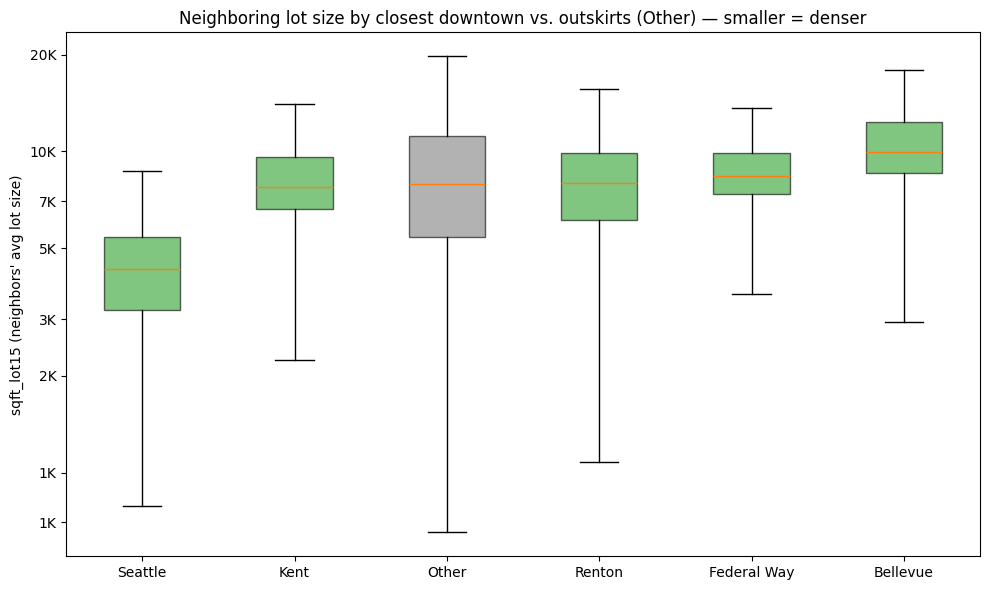

closest_town
Seattle       4320.000
Kent          7757.500
Other         7906.000
Renton        7983.500
Federal Way   8374.000
Bellevue      9958.000
Name: median_sqft_lot15, dtype: float64

In [28]:
order_by_density = (
    df_clean.groupby("closest_town")["sqft_lot15"].median().sort_values(ascending=True).index
)  # towns sorted smallest to largest median neighboring lot size (densest first)
data_by_town_lot = [
    df_clean.loc[df_clean["closest_town"] == town, "sqft_lot15"] for town in order_by_density
]  # lot-size values per town, in that order

fig, ax = plt.subplots(figsize=(10, 6))
box_colors = ["tab:gray" if town == "Other" else "tab:green" for town in order_by_density]  # gray out "Other" so downtowns stand out
bp = ax.boxplot(data_by_town_lot, labels=order_by_density, patch_artist=True, showfliers=False)  # hide outlier points to keep the plot readable
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)


def format_sqft(value, _pos):
    """axis tick label, e.g. 5_000 -> '5K', 50_000 -> '50K'"""
    return f"{value / 1_000:.0f}K"


ax.set_yscale("log")  # log scale since lot size is heavily skewed
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0, 7.0)))  # more tick marks than default log scale gives
ax.yaxis.set_minor_locator(mticker.NullLocator())  # no minor ticks, keep it clean
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_sqft))  # show ticks in thousands of sqft
ax.set_ylabel("sqft_lot15 (neighbors' avg lot size)")
ax.set_title("Neighboring lot sizes for each downtown (Other = outskirts). Smaller lots = denser")
plt.tight_layout()
plt.show()

df_clean.groupby("closest_town")["sqft_lot15"].median().reindex(order_by_density).rename("median_sqft_lot15")  # median lot size table, same order as the chart

### Testing hypothesis 2: downtown vs. outskirts (all homes)

Same nonparametric approach as Hypothesis 1 (`sqft_lot15` is skewed, same as `sqft_lot`), but one-sided the other way: testing whether downtown lots are *smaller* than outskirts lots. This uses the full dataset, not just Nicole's 1-2 bedroom bucket — density is a property of the neighborhood, not of a specific home size.

In [29]:
downtown_lot = df_clean.loc[df_clean["closest_town"] != "Other", "sqft_lot15"]  # neighboring lot sizes, downtown homes
outskirts_lot = df_clean.loc[df_clean["closest_town"] == "Other", "sqft_lot15"]  # neighboring lot sizes, outskirts homes

median_downtown_lot = downtown_lot.median()
median_outskirts_lot = outskirts_lot.median()
pct_diff_lot = (median_downtown_lot / median_outskirts_lot - 1) * 100  # % difference, downtown vs. outskirts

print(f"downtown median sqft_lot15:  {median_downtown_lot:,.0f}  (n={len(downtown_lot)})")
print(f"outskirts median sqft_lot15: {median_outskirts_lot:,.0f}  (n={len(outskirts_lot)})")
print(f"downtown lots are {pct_diff_lot:.1f}% vs. outskirts")

stat_lot, p_value_lot = mannwhitneyu(downtown_lot, outskirts_lot, alternative="less")  # test: are downtown lots smaller than outskirts?
print(f"\nMann-Whitney U statistic: {stat_lot:,.0f}")
print(f"p-value (one-sided, downtown < outskirts): {p_value_lot:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value_lot < alpha}")

downtown median sqft_lot15:  7,300  (n=10160)
outskirts median sqft_lot15: 7,906  (n=11436)
downtown lots are -7.7% vs. outskirts

Mann-Whitney U statistic: 48,790,532
p-value (one-sided, downtown < outskirts): 2.469e-92
statistically significant at alpha=0.05: True


### All 5 downtowns vs. outskirts, individually

Same generalization as Hypothesis 1 — pooling all 5 downtowns can hide the fact that some are denser than others. This checks each city separately against the same outskirts group.

In [30]:
density_results = []
for town in DOWNTOWNS:
    town_lot = df_clean.loc[df_clean["closest_town"] == town, "sqft_lot15"]  # lot sizes for this town's homes
    median_town_lot = town_lot.median()
    pct_diff = (median_town_lot / median_outskirts_lot - 1) * 100  # % difference vs. outskirts
    stat, p = mannwhitneyu(town_lot, outskirts_lot, alternative="less")  # test: is this town's lot size smaller than outskirts?
    density_results.append(
        {
            "city": town,
            "n": len(town_lot),
            "median_sqft_lot15": median_town_lot,
            "pct_diff_vs_outskirts": round(pct_diff, 1),
            "p_value": p,
            "significant": p < alpha,
        }
    )

density_results_df = pd.DataFrame(density_results).set_index("city").sort_values("median_sqft_lot15")  # one row per city, smallest lots first

print(f"outskirts median sqft_lot15 for comparison: {median_outskirts_lot:,.0f}  (n={len(outskirts_lot)})")
print()

display_density = density_results_df.copy()
display_density["median_sqft_lot15"] = display_density["median_sqft_lot15"].map(lambda x: f"{x:,.0f}")  # format for display
display_density["p_value"] = display_density["p_value"].map(lambda x: f"{x:.2e}")  # format in scientific notation for display
display_density

outskirts median sqft_lot15 for comparison: 7,906  (n=11436)



,n,median_sqft_lot15,pct_diff_vs_outskirts,p_value,significant
city,,,,,
Seattle,3467,"4,320",-45.400,0.00e+00,True
Kent,1274,"7,758",-1.900,2.00e-01,False
Renton,2296,"7,984",1.000,2.64e-01,False
Federal Way,1266,"8,374",5.900,1.00e+00,False
Bellevue,1857,"9,958",26.000,1.00e+00,False


### Density-based shortlist: dense downtowns in Nicole's price range

Nicole's priority is a lively (dense) area, not necessarily the priciest one — requiring Hypothesis 1's price-premium significance on top of density was too strict. A downtown can be genuinely dense without also being the most expensive, and a lower price there is a plus for Nicole, not a strike against the recommendation. This shortlist only requires a downtown to pass the Hypothesis 2 density test.

For price, rather than each downtown's own mid-price band (used in the Hypothesis 1 shortlist), this uses one price ceiling pooled across all the towns that pass the density test. Reason: a "cheap for Seattle" home can already be a typically-priced home in a cheaper downtown like Kent — a per-town band would wrongly exclude it. The ceiling is the 75th percentile of pooled prices for Nicole's target bucket (1-2 bed, 485-645 sqft) across those dense downtowns; anything cheaper than that is fine too.

In [ ]:
dense_towns = density_results_df[density_results_df["significant"]].index.tolist()  # towns that pass the H2 density test
print(f"Dense towns (pass H2 significance test): {dense_towns}")

dense_bucket = downtown_bucket[
    downtown_bucket["sqft_living"].between(SQFT_LOW, SQFT_HIGH)  # Nicole's target size
    & downtown_bucket["closest_town"].isin(dense_towns)  # only towns that are genuinely denser than outskirts
].copy()

price_low, price_high = dense_bucket["price"].quantile([0.25, 0.75])  # pooled mid-price band across all dense towns
print(f"Pooled mid-price band across dense downtowns: ${price_low:,.0f} - ${price_high:,.0f}")

density_shortlist = dense_bucket[dense_bucket["price"] <= price_high].copy()  # cap at the 75th percentile; cheaper is fine too

print(f"{len(density_shortlist)} homes match: 1-2 bed, 485-645 sqft, in a dense downtown, priced at or below ${price_high:,.0f}")
density_shortlist["closest_town"].value_counts()  # how many shortlisted homes per town

In [ ]:
density_shortlist.sort_values(["closest_town", "price"])[shortlist_cols].head(20)  # preview the first 20 shortlisted homes, grouped by town

### Takeaway for Nicole

- This shortlist only requires a downtown to clear the H2 density bar — being genuinely built-up, not just close to a city-center point. A dense downtown that also happens to be cheaper is a good outcome for Nicole, not a weaker one, so Hypothesis 1's price-premium significance is no longer a requirement here.
- The price ceiling (75th percentile) is pooled across all qualifying dense downtowns rather than set per town, so a home that's cheap for Seattle but typically-priced for a cheaper downtown like Kent isn't excluded just because of which downtown it's near.
- **Caveat to carry into the recommendation:** `sqft_lot15` is a proxy, not a direct measure of "lively" — it captures density, not things like walkability or nightlife that aren't in this dataset. And as noted earlier, this is sold-homes data from May 2014-May 2015, not live listings — use these towns and price ceiling as a filter on current listings, not a literal call list.

## Hypothesis 3: seasonality in sales volume and price

Two claims to test:
1. **Sales volume peaks in summer.**
2. **Winter prices are up to 5% cheaper** than the rest of the year.

**Seasons are defined by calendar month:** Winter = Dec/Jan/Feb, Spring = Mar/Apr/May, Summer = Jun/Jul/Aug, Fall = Sep/Oct/Nov.

**Caveat:** the dataset covers a single 13-month window (2014-05-02 to 2015-05-27) — one full seasonal cycle, not multiple years. That's enough to compare "this past summer" vs. "this past winter", but not enough to separate a true recurring seasonal pattern from a one-off trend that happened to occur in that particular year.

In [32]:
df_clean["date"] = pd.to_datetime(df_clean["date"])  # parse date strings into real datetime values
df_clean["sale_month"] = df_clean["date"].dt.month  # extract the calendar month (1-12)

SEASON_MAP = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall",
}  # month number -> season name
df_clean["season"] = df_clean["sale_month"].map(SEASON_MAP)

season_order = ["Winter", "Spring", "Summer", "Fall"]  # display order for charts/tables below
df_clean["season"].value_counts().reindex(season_order)  # sale count per season, in that order

season
Winter    3695
Spring    6518
Summer    6327
Fall      5056
Name: count, dtype: int64

### Sales volume by month and season

Every calendar month appears once in the window except May, which appears twice (partial May 2014 and partial May 2015) — together they add up to roughly one May's worth of sales, so pooling by season doesn't double-count a month.

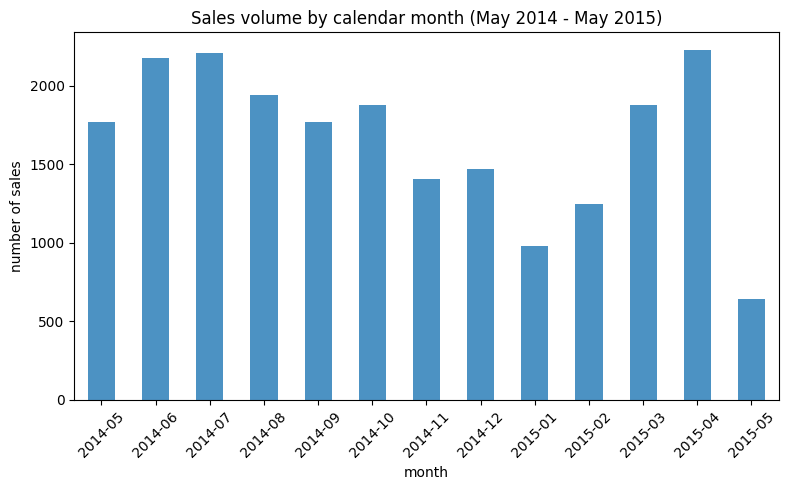

In [33]:
monthly_counts = df_clean.groupby(df_clean["date"].dt.to_period("M")).size()  # number of sales per calendar month

fig, ax = plt.subplots()
monthly_counts.plot(kind="bar", ax=ax, color="tab:blue", alpha=0.8)
ax.set_xlabel("month")
ax.set_ylabel("number of sales")
ax.set_title("Sales volume by calendar month (May 2014 - May 2015)")
plt.xticks(rotation=45)  # angle month labels so they don't overlap
plt.tight_layout()
plt.show()

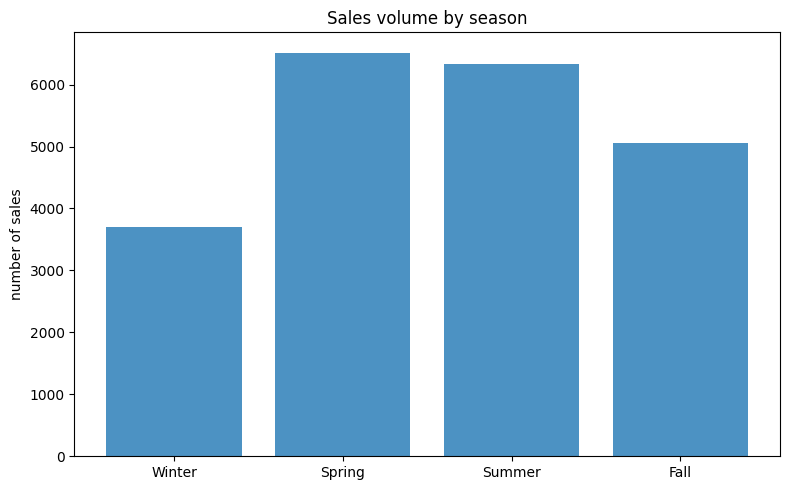

,count,share_%
season,,
Winter,3695,17.100
Spring,6518,30.200
Summer,6327,29.300
Fall,5056,23.400


In [34]:
season_counts = df_clean["season"].value_counts().reindex(season_order)  # sale count per season, in display order
season_share = (season_counts / season_counts.sum() * 100).round(1)  # same counts as a % of all sales

fig, ax = plt.subplots()
ax.bar(season_order, season_counts, color="tab:blue", alpha=0.8)
ax.set_ylabel("number of sales")
ax.set_title("Sales volume by season")
plt.tight_layout()
plt.show()

pd.concat([season_counts.rename("count"), season_share.rename("share_%")], axis=1)  # counts and shares side by side

### Testing the volume claim

All four seasons span roughly the same number of days (~91-92), so if sales were spread evenly through the year each season would get about 25% of them. A chi-square goodness-of-fit test checks whether the observed season counts depart from that even 25%-each split, then we check whether the peak specifically lands on summer.

In [35]:
from scipy.stats import chisquare

alpha = 0.05
observed = season_counts.values  # actual sale counts per season
expected = np.full(4, observed.sum() / 4)  # what an even 25%-per-season split would look like

chi2_stat, p_value_chi2 = chisquare(observed, expected)  # test: does the seasonal split differ from even?

print(f"chi-square statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value_chi2:.4g}")
print(f"statistically significant departure from an even 25%-per-season split at alpha={alpha}: {p_value_chi2 < alpha}")
print()
print(f"season with the most sales: {season_counts.idxmax()} ({season_counts.max():,} sales, {season_share.max()}% of the year)")
print(f"summer is the peak season: {season_counts.idxmax() == 'Summer'}")

chi-square statistic: 951.03
p-value: 7.551e-206
statistically significant departure from an even 25%-per-season split at alpha=0.05: True

season with the most sales: Spring (6,518 sales, 30.2% of the year)
summer is the peak season: False


### Price by season

Compare median price in winter against the rest of the year (the specific claim is about winter, not all four seasons pairwise). Used a Mann-Whitney U test rather than a t-test since price is skewed and this is a median comparison, matching the approach used for Hypothesis 1.

In [36]:
season_median_price = df_clean.groupby("season")["price"].median().reindex(season_order)  # median price per season, in display order
print(season_median_price.map(lambda x: f"${x:,.0f}"))

winter_price = df_clean.loc[df_clean["season"] == "Winter", "price"]  # prices of homes sold in winter
rest_price = df_clean.loc[df_clean["season"] != "Winter", "price"]  # prices of homes sold in any other season

median_winter = winter_price.median()
median_rest = rest_price.median()
pct_diff = (median_winter / median_rest - 1) * 100  # % difference, winter vs. rest of year

print(f"\nwinter median price:       ${median_winter:,.0f}  (n={len(winter_price)})")
print(f"rest-of-year median price: ${median_rest:,.0f}  (n={len(rest_price)})")
print(f"winter is {abs(pct_diff):.1f}% {'lower' if pct_diff < 0 else 'higher'} than the rest of the year")
print(f"matches the 'up to 5% cheaper' claim: {-5 <= pct_diff <= 0}")

season
Winter    $430,000
Spring    $465,000
Summer    $455,000
Fall      $443,725
Name: price, dtype: str

winter median price:       $430,000  (n=3695)
rest-of-year median price: $455,000  (n=17901)
winter is 5.5% lower than the rest of the year
matches the 'up to 5% cheaper' claim: False


In [37]:
stat_season, p_value_season = mannwhitneyu(winter_price, rest_price, alternative="less")  # test: is winter price lower than the rest of the year?

print(f"Mann-Whitney U statistic: {stat_season:,.0f}")
print(f"p-value (one-sided, winter < rest of year): {p_value_season:.4g}")
print(f"statistically significant at alpha={alpha}: {p_value_season < alpha}")

Mann-Whitney U statistic: 31,133,673
p-value (one-sided, winter < rest of year): 9.647e-09
statistically significant at alpha=0.05: True


### Controlling for house characteristics

A raw price gap between seasons could just mean different *kinds* of houses sell in different seasons (e.g. bigger homes selling more in summer) rather than a true seasonal discount. To isolate a "season effect", regress `price` on the house's own characteristics (size, bedrooms, bathrooms, grade, condition, waterfront, view) plus zipcode (as a location control) and season, using Summer as the reference season. The Winter coefficient reads as an approximate $ price effect *holding those features constant* — a cleaner test of "winter itself" than the raw median comparison above.

In [ ]:
import statsmodels.formula.api as smf

reg_df = df_clean.copy()
reg_df["season"] = pd.Categorical(reg_df["season"], categories=season_order)  # fix category order so "Summer" can be the reference level below
reg_df["zipcode"] = reg_df["zipcode"].astype(str)  # treat zipcode as a category, not a number, in the regression

model = smf.ols(
    "price ~ C(season, Treatment(reference='Summer')) + sqft_living + bedrooms + bathrooms "
    "+ grade + condition + waterfront + view + C(zipcode)",
    data=reg_df,
).fit()  # regress price on season plus house characteristics, controlling for zipcode

season_coefs = model.params.filter(like="season")  # regression coefficients for each season (vs. Summer), in dollars
season_pvals = model.pvalues.filter(like="season")  # p-values for those coefficients

season_summary = pd.DataFrame(
    {
        "price_effect": season_coefs,
        "p_value": season_pvals,
    }
)
season_summary.index = season_summary.index.str.extract(r"T\.(\w+)\]")[0].values  # clean up index labels, e.g. "...[T.Winter]" -> "Winter"
season_summary["significant"] = season_summary["p_value"] < alpha
season_summary

### Takeaway

- **Volume:** see the chi-square result above for whether sales are unevenly spread across seasons, and whether summer specifically is the peak.
- **Price:** the raw winter-vs-rest median gap (Mann-Whitney test) is the direct read on the "~5% cheaper" claim. The regression above adds a second check — after controlling for house size, quality, and zipcode, does a "winter" effect on price still show up, and is it still in the ballpark of ~5%?
- **Caveat to carry forward:** both results describe one observed year (2014-2015). Treat this as a first read on seasonality, not proof of a recurring pattern — confirming it would need sales data spanning multiple years.